# Градиентный бустинг

Эта практика является прямым продолжением практики про обучение ансамблей. Тут пойдёт разговор про главный вид ансамблей $-$ **градиентный бустинг**. Как понятно из названия, это ещё один способ построения бустинга.


В бустинге мы хотели соединять модели последовательно, чтобы каждая следующая модель компенсировала ошибки предыдущих моделей.

$$F_t(x)=F_{t-1}(x)+\alpha_tf_t(x),$$

$F_t$ $-$ новая модель, $F_{t-1}$ $-$ имеющаяся модель (зафиксирована, не изменяется), $f_t$ $-$ обучаемая часть. Коэффициент $\alpha_t$ часто называют темпом обучения (learning rate).

Идея **градиентного бустинга** заключается в том, чтобы подойти к задаче построения ансамбля с точки зрения минимизации некоторой общей функции ошибки. Пусть у нас уже обучены модели $f_1,\dots,f_{T-1}$, а мы хотим обучить очередную модель $f_T$. Предсказание выглядит как среднее по предсказаниям всех моделей: $\hat{y}=\sum_{t=1}^{T}f_t(\overline{x})$. Модель минимизирует функцию ошибки: $$L=\sum_{i=1}^N l(y_i,\hat{y}_i)+\sum_{t=1}^{T}\Omega(f_t)\rightarrow \min$$ где $\Omega$ $-$ регуляризация, накладываемая на обучаемые модели.

Заметим, что модели $f_1,\dots,f_{T-1}$ зафиксированы, а обучается лишь $f_T$, тогда функция ошибки имеет другой вид:

$$L^{(T)}=Const+\sum_{i=1}^N l(y_i,\hat{y}_i^{(T-1)}+f_T(\overline{x}_i))+\Omega(f_T)\rightarrow\min,$$

где $\hat{y}_i^{(T-1)}$ - предсказание, полученное с помощью первых $(T-1)$ моделей.

Мы можем разложить функцию ошибки $l(y_i,\hat{y}_i^{(T-1)}+f_T(\overline{x}_i))$ в ряд Тейлора, предполагая что $f_T(\overline{x}_i)$ -  это малая величина:

$$l(y_i,\hat{y}_i^{(T-1)}+f_T(\overline{x}_i))=l(y_i,\hat{y}_i^{(T-1)})+\left.\frac{\partial l}{\partial \hat{y}}\right|_{\hat{y}^{(T-1)}}f_T(\overline{x}_i)+\left.\frac{1}{2}\frac{\partial^2l}{\partial\hat{y}^2}\right|_{\hat{y}^{(T-1)}}f_T^2(\overline{x}_i)+O(f_T^3(\overline{x}_i)).$$

В результате мы получим функцию ошибки: 

$$L\approx\sum_{i=1}^N(g_if_T(\overline{x}_i)+\frac{h_i}{2}f_T^2(\overline{x}_i))+\Omega(f_T)\rightarrow\min$$

Такой трюк позволяет перейти от задачи минимизации общей функции ошибки (в которой участвуют все составляющие ансамбля) к задаче обучения одной из составляющих ансамбля.

**Gain**, на основании которого строятся разбиения узлов, будет вычисляться на основании полученного приближения $L$.

Для **регрессии** можно использовать среднеквадратичную функцию ошибки или любую другую.

Если решается задача **классификации**, то в качестве функции ошибки используется кросс-энтропия. Для каждого класса обучается свой ансамбль, а для получения предсказаний применяется $\text{softmax}$. Это также означает, что ансамбли бустинга *умеют предсказывать вероятности*, но надо не забывать проверять калибровку моделей.

## XGBoost

Рассмотрим как работает один из популярных алгоритмов бустинга с решающими деревьями. Рассмотрим на примере задачи регрессии. Пусть у дерева есть $M$ листов. Мы знаем набор значений в его листах $\overline{w}\in \R^M$ и функцию принятия решений $q: \R^n\rightarrow\{1,2,\dots,M\}$, которая для входов определяет в какой лист мы попадём. Тогда результат работы дерева можно записать следующим образом:

$$f_T(\overline{x})=w_{q(\overline{x})}.$$

В качестве регуляризатора возьмём следующую функцию: $\Omega(f_t)=\gamma M + \frac{\lambda}{2}\sum_{i=1}^{M}w_i^2$, включающая штраф за размер дерева и величину весов $\overline{w}$. 

Из этих предпосылок можно вывести следующий критерий для построения разбиения узла $S$ на узлы $L$ и $R$:

$$Gain=\frac{1}{2}\left(\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{G_S^2}{H_S+\lambda}\right)-\gamma.$$

А веса $w_i$ в листе $i$ определяются по формуле: $w_i=-\frac{G_i}{H_i+\lambda}$.

Величины $G$ и $H$ это суммы первых и вторых производных целевой функции по y: $$G_i=\sum_{n:q(\overline{x}_n)\in i} g_n=\sum_{n:q(\overline{x}_n)\in i}\left.\frac{\partial l}{\partial \hat{y}}\right|_{\hat{y}_n^{(T-1)}}\;\;\text{и}\;\;H_i=\sum_{n:q(\overline{x}_n)\in i} h_n=\sum_{n:q(\overline{x}_n)\in i}\left.\frac{\partial^2 l}{\partial \hat{y}^2}\right|_{\hat{y}_n^{(T-1)}}.$$

Значения $h_n$ и $g_n$ это некоторые веса, назначаемые моделью точкам данных. В процессе обучения дерева $f_T$ значения $h_n$ и $g_n$ не меняются, поскольку определяются предсказаниями уже обученных моделей.

Получается, что метод градиентного бустинга меняет критерий разбиения так, чтобы напрямую минимизировать желаемую функцию ошибки с учётом регуляризации.

Идеи градиентного бустинга общие для разных библиотек. Основные различия в библиотеках в трюках, применяемых при обучении.

Давайте снова загрузим уже знакомый нам набор данных и попробуем обучить на нём градиентный бустинг:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
import scipy

In [20]:
df = pd.read_csv("/home/ivanbalashov/LearningMachine/twelve/train_cat_in_dat.zip", index_col="id")

print("Количество строк:", len(df))
print("Количество столбцов:", len(df.columns))
df.head()

Количество строк: 300000
Количество столбцов: 24


,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month,target
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,T,Y,Green,Triangle,Snake,Finland,Bassoon,...,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2,0
1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,Piano,...,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8,0
2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,Theremin,...,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2,0
3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,Oboe,...,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1,1
4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,Oboe,...,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8,0


Столбцы *bin* - бинарные, *nom* - категориальные (номинальные), *ord* - порядковые (ординальные).

Вычислим количество уникальных значений в каждом столбце:

In [21]:
print("Столбец | Количество уникальных значений")
for col in df.columns:
    print(f"{col:8}| {df[col].nunique()}")

Столбец | Количество уникальных значений
bin_0   | 2
bin_1   | 2
bin_2   | 2
bin_3   | 2
bin_4   | 2
nom_0   | 3
nom_1   | 6
nom_2   | 6
nom_3   | 6
nom_4   | 4
nom_5   | 222
nom_6   | 522
nom_7   | 1220
nom_8   | 2215
nom_9   | 11981
ord_0   | 3
ord_1   | 5
ord_2   | 6
ord_3   | 15
ord_4   | 26
ord_5   | 192
day     | 7
month   | 12
target  | 2


Мы сразу можем заметить следующую проблему: применение one-hot encoding невозможно для столбцов nom_5-nom_9.

Пока мы закодируем числами имеющиеся признаки. Для ординальных признаков соблюдём их порядок. Для столбцов ord_3-ord_5 указано, что их порядок - лексикографический.

In [22]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

# кодируем все столбцы, кроме ординальных, дат и целевой переменной
for_le = set(df.columns) - {"target", "day", "month", "ord_0", "ord_1", "ord_2", "ord_3", "ord_4", "ord_5"}
for col in for_le:
    df[col] = LabelEncoder().fit_transform(df[col])

Для дня недели и месяца добавим признаки, позволяющие описывать сезонность. Извлечём синус и косинус.

In [23]:
df["day_sin"] = np.sin(df["day"] / 7 * 2 * np.pi)
df["day_cos"] = np.cos(df["day"] / 7 * 2 * np.pi)
df["month_sin"] = np.sin(df["month"] / 12 * 2 * np.pi)
df["month_cos"] = np.cos(df["month"] / 12 * 2 * np.pi)
df.drop(columns=["day","month"], inplace=True)

In [24]:
ord_to_order = {"ord_0": [1, 2 , 3],
                "ord_1": ["Novice", "Contributor", "Expert", "Master", "Grandmaster"],
                "ord_2": ["Freezing", "Cold", "Warm", "Hot", "Boiling Hot", "Lava Hot"]
                }

for col in ["ord_3", "ord_4", "ord_5"]:
    ord_to_order[col] = sorted(list(df[col].value_counts().index))

cols   = list(ord_to_order.keys())
values = list(ord_to_order.values())

df[cols] = OrdinalEncoder(categories=values).fit_transform(df[cols]).astype(int)

In [25]:
X = df.drop(columns="target")
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=43)

In [26]:
from xgboost import XGBClassifier
import xgboost as xgb

model = XGBClassifier()

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.8240
test ROC AUC: 0.7673
test Accuracy: 0.7437


Сразу можно заметить, что модель значительно переобучилась, но вместе с тем показала лучшее качество.

Полный набор принимаемых параметров можно посмотреть в [документации](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier). Основные параметры модели следующие.
- n_estimators - количество деревьев в ансамбле.
- max_depth - максимальная глубина каждого из деревьев.
- learning_rate - "темп обучения" - вклад каждого нового дерева в ансамбль: $f_T(x)=f_{T-1}(x)+\alpha f(x)$, где $\alpha$ - темп обучения.
- gamma - коэффициент регуляризации из функции ошибки - минимальное изменение функции ошибки для получения нового разбиения узла.
- reg_lambda - коэффициент $L_2$ регуляризации, накладываемой на веса в листах.

Библиотека также имеет возможности для добавления бутстреппинга в обучение. Для этого есть параметры:
- subsample - доля выборки, которую получает каждое дерево.
- colsample_bytree - доля столбцов, которые получает каждое дерево.
- и другие.

Таким образом, мы можем включить в бустинг основное достоинство слуйчайного леса $-$ снижение дисперсии(переобучения) за счёт получения "разных" моделей, обученных на случайных подвыборках. Получается, что случайный лес это "дешёвая версия" градиентного бустинга.

Также надо отметить, что по-умолчанию в бустинге часто отсутствует обрезка деревьев (pruning). Сделано это для ускорения обучения. Поэтому мы не видим связанных с этим параметров. Но при необходимости обрезку [можно добавить](https://xgboost.readthedocs.io/en/stable/treemethod.html#other-updaters).

Перед запуском кросс-валидации я попробую руками подобрать параметры.

"При желании" модель можно переобучить вплоть до запоминаний всей выборки, но это не наша итоговая цель.

In [27]:
model = XGBClassifier(n_estimators=1000)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.9756
test ROC AUC: 0.7472
test Accuracy: 0.7304


Мы можем начать вводить ограничения на размер деревьев.

In [28]:
model = XGBClassifier(max_depth=2, n_estimators=1000)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.7931
test ROC AUC: 0.7809
test Accuracy: 0.7523


Значение метрики ROC AUC 0.7808 пока самое большое из всех, что мы получали на этом наборе данных.

А теперь попробуем обучить гиперпараметры. Для экономии времени возьмём маленькую обучающую выборку.

In [29]:
X = df.drop(columns="target")
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.8, stratify=Y, random_state=43)

In [53]:
n_iter = 100
cv = 3

param_dist= {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(1, 6),
    "learning_rate": loguniform(1e-3, 0.5),
    "gamma": loguniform(1e-3, 5),
    "reg_lambda": loguniform(1e-3, 10),
}

estimator = XGBClassifier(
    )

total_fits = n_iter * cv

rnd_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=n_iter,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False
)

rnd_search.fit(X_train, Y_train)

model = rnd_search.best_estimator_
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

print("Полученные параметры:")
rnd_search.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END gamma=0.004497317913391921, learning_rate=0.001976882041091017, max_depth=1, n_estimators=952, reg_lambda=9.6699993140058; total time=  15.0s
[CV] END gamma=0.004497317913391921, learning_rate=0.001976882041091017, max_depth=1, n_estimators=952, reg_lambda=9.6699993140058; total time=  15.9s
[CV] END gamma=0.004497317913391921, learning_rate=0.001976882041091017, max_depth=1, n_estimators=952, reg_lambda=9.6699993140058; total time=  16.5s
[CV] END gamma=0.14112272631247155, learning_rate=0.0030687540436449227, max_depth=2, n_estimators=819, reg_lambda=0.00252527139362845; total time=  18.5s
[CV] END gamma=0.14112272631247155, learning_rate=0.0030687540436449227, max_depth=2, n_estimators=819, reg_lambda=0.00252527139362845; total time=  18.5s
[CV] END gamma=0.14112272631247155, learning_rate=0.0030687540436449227, max_depth=2, n_estimators=819, reg_lambda=0.00252527139362845; total time=  20.4s
[CV] END gamma=0.11

{'gamma': np.float64(0.13770049957659888),
 'learning_rate': np.float64(0.2745877610604167),
 'max_depth': 3,
 'n_estimators': 890,
 'reg_lambda': np.float64(0.0012555948248299472)}

Значительно лучших результатов добиться не удаётся. Это может быть связанно с недостаточным объёмом перебранных параметров или с тем, что модель в данном случае достигла своего предела. А более высокий результат, что был продемонстрирован выше $-$ уже знакомый нам эффект переобучения гиперпараметров на тестовой выборке. 

Чтобы качественно лучших результатов нужно более качественно обработать данные, к примеру $-$ обработать категориальные признаки.

В библиотеке xgboost есть поддержка работы с категориальными признаками, для этого надо указать параметр `enable_categorical = True`. А чтобы столбец распознавался как категориальный надо указать в таблице pandas тип столбца `category`. Условия разбиения для категориальных признаков может иметь два вида: 
- $category==value$ Такое разбиение эквивалентно one-hot кодированию.
- $category\in values$ Такой подход агрегирует похожие категории.

Параметр `max_cat_to_onehot` определяет порог количества категорий, для которых применяется one-hot кодирование.

In [31]:
X_train_c = X_train.copy()
X_test_c = X_test.copy()

for col in X_train_c.columns:
    if "nom" in col or "bin" in col:
        X_train_c[col] = X_test_c[col].astype("category")
        X_test_c[col] = X_test_c[col].astype("category")

model = XGBClassifier(max_depth=7, n_estimators=1000, device="cpu", n_jobs=-1, 
                    gamma=1, subsample=0.9, colsample_bytree=0.5,
                    enable_categorical=True,  max_cat_to_onehot=6)

model.fit(X_train_c, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train_c)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test_c)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test_c)):.4f}")

train ROC AUC: 0.8161
test ROC AUC: 0.7133
test Accuracy: 0.7175


В данном случае, добавление обработки категориальных столбцов не сделало лучше. 

Немного поэксперементировав с параметрами, становится понятно, что модель стала более склонна к переобучению.

## Catboost

CatBoost это библиотека, разработанная компанией "Яндекс" в 2017 году. Основной упор в библиотеке сделан на обработку категориальных признаков. Основные методические новшества CatBoost включают процедуру ordered boosting и алгоритмы построения статистик по категориям (CTR-признаки) с использованием перестановок.

Основная идея обработки категориальных признаков - применение  целевого кодирования (TargetEncoding) - метод, когда категория кодируется средним значением целевой переменной по этой категории. Сам по себе метод очень склонен приводить к переобучению, так как приводит к явной утечке целевой переменной в признаки. CatBoost и пытается бороться с этой проблемой с помощью разных трюков.

Также CatBoost отличается от XGBoost в построении деревьев. CatBoost строит деревья, где на одном уровне в каждом узле получаются одинаковые условия разбиения. Такая *структурная регуляризация* позволяет ускорить вычисления и уменьшить переобучение.

In [32]:
from catboost import CatBoostClassifier, Pool

Давайте сравним получаемые деревья этими двумя библиотеками при ограничении глубины дерева 2.

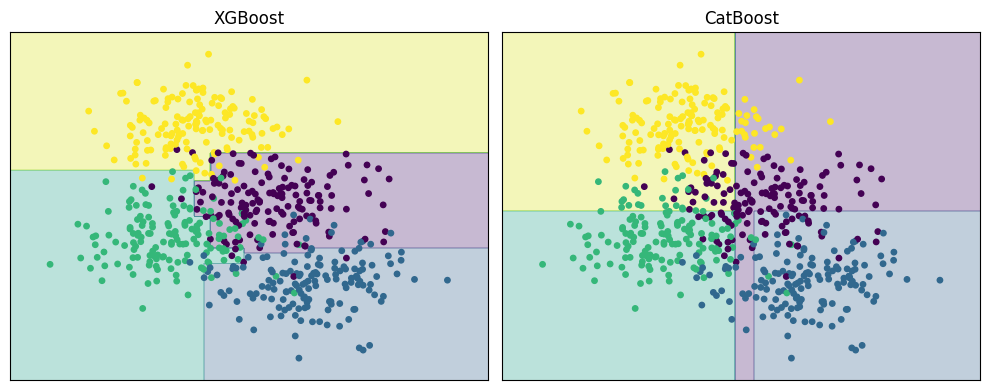

In [33]:
from sklearn.datasets import make_blobs
X1, y1 = make_blobs(n_samples=600, centers=4, cluster_std=1.2, random_state=0)

xgb = XGBClassifier(n_estimators=1, max_depth=3, verbosity=0).fit(X1, y1)
cb  = CatBoostClassifier(iterations=1, max_depth=3, verbose=0).fit(X1, y1)

xx, yy = np.meshgrid(np.linspace(X1[:,0].min()-1, X1[:,0].max()+1, 300),
                     np.linspace(X1[:,1].min()-1, X1[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, ax = plt.subplots(1, 2, figsize=(10,4))
for a, clf, title in [(ax[0], xgb, "XGBoost"), (ax[1], cb, "CatBoost")]:
    Z = clf.predict(grid).reshape(xx.shape)
    a.contourf(xx, yy, Z, alpha=0.3)
    a.scatter(X1[:,0], X1[:,1], c=y1, s=15)
    a.set_title(title); a.set_xticks([]); a.set_yticks([])

plt.tight_layout(); plt.show()

Деревья можно также отобразить:

Catboost:


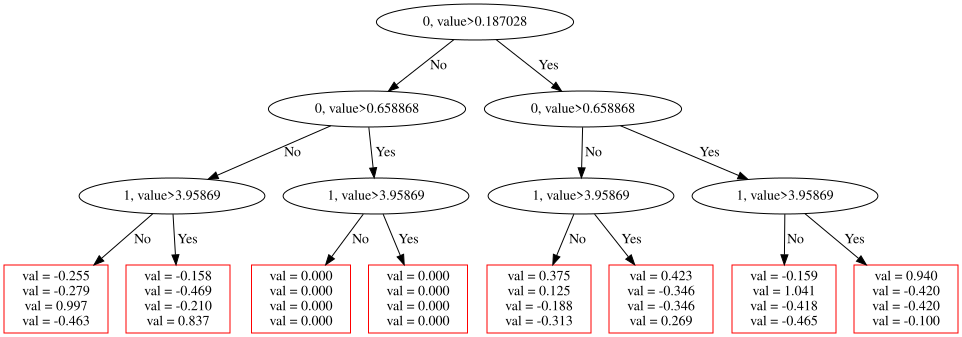

XGBoost:


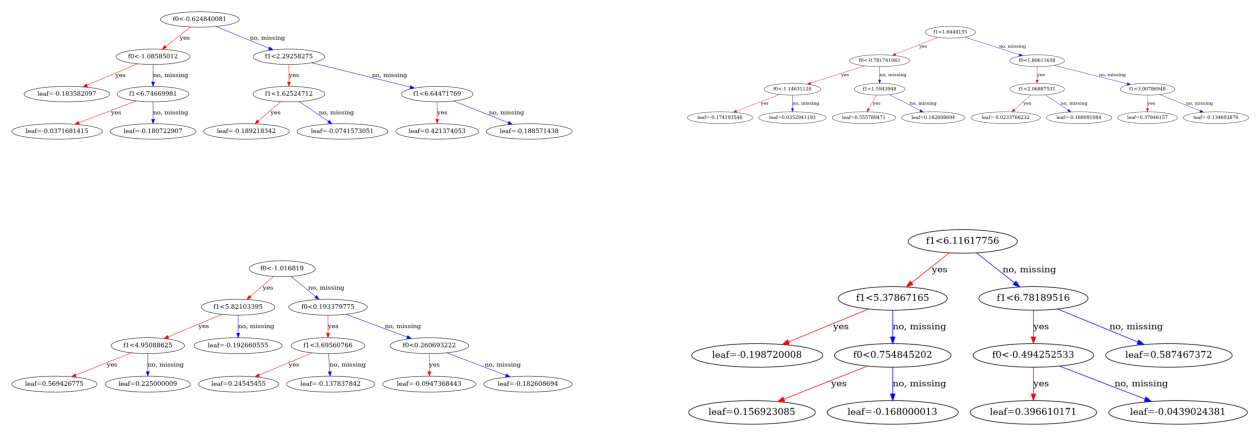

In [34]:
from xgboost import plot_tree
import pydotplus
from IPython.display import Image, display


print("Catboost:")
graph = cb.plot_tree(tree_idx=0)
display(graph)
print("XGBoost:")
fig,axes = plt.subplots(2,2)
fig.set_size_inches(16,6)
axes = axes.flatten()
for i in range(4):
    plot_tree(xgb, tree_idx=i,ax=axes[i])
plt.show()

Тут мы обнаруживаем ещё интересное замечание: 
- **XGBoost** построил 4 дерева глубины 2: по дереву для каждого класса,
- **CatBoost** одно дерево, в листах которого предсказываются логиты сразу для всех классов.

In [35]:
X = df.drop(columns="target")
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=43)

In [36]:
model = CatBoostClassifier(verbose=0)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.8143
test ROC AUC: 0.7773
test Accuracy: 0.7498


In [37]:
model = CatBoostClassifier(iterations=1000, max_depth=5, learning_rate=0.5, verbose=0)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.8569
test ROC AUC: 0.7624
test Accuracy: 0.7399


## Обработка категориальных признаков в CatBoost

Давайте разберёмся что делает CatBoost при обработке категориальных признаков. 

Мы уже знаем два основных подхода к обработке категориальных признаков:
- **One-Hot кодирование** Проблема этого метода в том, что при его применении сильно возрастает размерность признакового пространства. При применении метода к признаку, имеющему 1000 категорий, будет получен 1000-мерный вектор.
- **Target (Целевое) Кодирование** Проблема этого метода в том, что он часто приводит к переобучению, так как приводит к утечке целевой переменной в признаковое пространство напрямую.

Следующая методика направлена на борьбу с переобучением, возникающим при применении Целевого кодирования.

1. **Упорядоченное кодирование (Ordered Target Statistics).** Обычно в целевом кодировании используется метод "Leave-One-Out" $-$ целевые статистики для объектов вычисляются по всем точкам, кроме той точки, для которой вычисляется статистика. Но это не предотвращает утечку данных.

    В CatBoost генерируется случайная перестановка точек данных. Целевые статистики для точек вычисляются только по точкам данных, которые имеют меньший номер. Такой подход направлен на то, чтобы уменьшить утечку целевой переменной: теперь статистика вычисляется не по всей выборке, а также для разных точек данных значение статистики будет отличаться.

    В виде формулы это можно записать следующи образом:
    $$\text{TS}_i = \frac{\sum_{j=1}^{i-1} \mathbb{I}[x_j = x_i] \cdot y_j + \text{prior}}{\sum_{j=1}^{i-1} \mathbb{I}[x_j = x_i] + 1}$$

2. **Лапласовское сглаживание.** У описанного ранее метода сразу можно заметить проблему: будут точки, дял которых предшествовало 0 точек из той же категории, для этих точек будет не от куда брать статистику. Но даже если не обращать внимание на такие крайние случаи всё равно останутся точки, для которых статистика будет считаться по малому набору данны. Поэтому статистики будут получаться шумными.

    Для решения описанной проблемы в формулу в числитель вносится $prior$ и в знаменатель $1$ для "сглаживания" получаемого значения. Значение $prior$ обычно берут как среднее целевой переменной по всему набору данных.

3. **Несколько случайных перестановок.** Для борьбы с описанными эффектами целевое кодирование формируется не по одной фиксированной перестановке, а по нескольким перестановкам.

    До запуска обучения в модели генерируется несколько независимых перестановок. Далее при построении каждого дерева  выбирается перестановка, по которой будет формироваться целевое кодирование. 

    Такой подход также вносит элемент бэггинга и мешает переобучиться модели под конкретное целевое кодирование, так как оно меняется от дерева к дереву.

Пока мы использовали CatBoost без поддержки категориальных признаков, давайте добавим их обработку.

In [38]:
categorical_features_indices = np.where(X_train_c.dtypes == "category")[0]

categorical_features_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

При обучении CatBoost можно указать валидационную выборку, на которой по ходу обучения деревьев будет оцениваться качество модели. Так получается, что параметр iterations (n_estimators) можно не перебирать, а взять какое-то большое значение. А обучение остановиться в тот момент, когда модель начнёт переобучаться, то есть метрика на валидационном множестве перестанет расти. Параметр `early_stopping_rounds` определяет количество итераций до остановки обучения, на которых не происходило увеличение метрики на валидационном множестве.

Важно заметить, что для действительно честной оценки качества валидационная и тестовая выборки не должны совпадать. Если они совпадают, то получится переобучение. 

In [42]:
params = {'loss_function': 'CrossEntropy', 
              'eval_metric': "AUC",
              'learning_rate': 0.01,
              'iterations': 1000,
              'random_seed': 42,
              'od_type': "Iter",
              'early_stopping_rounds': 500,
             }

X_train1, X_val1, Y_train1, Y_val1 = train_test_split(X_train, Y_train, test_size=0.3)

_train = Pool(X_train1, label=Y_train1, cat_features=categorical_features_indices)
_test = Pool(X_val1, label=Y_val1, cat_features=categorical_features_indices)

model = CatBoostClassifier(**params)

fit_model = model.fit(_train,
                    eval_set=_test,
                    use_best_model=True,
                    verbose=1000,
                    plot=False)

print()
print(f"validation ROC AUC: {roc_auc_score(Y_val1, model.predict_proba(X_val1)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

0:	test: 0.6953394	best: 0.6953394 (0)	total: 126ms	remaining: 2m 5s
999:	test: 0.7934653	best: 0.7934653 (999)	total: 2m 24s	remaining: 0us

bestTest = 0.7934653073
bestIteration = 999


validation ROC AUC: 0.7935
test ROC AUC: 0.7917
test Accuracy: 0.7557


Мы смогли добить довольно хорошего результата. Значение метрики на тестовом множестве равно $0.7961$. Причём мы не переобучили модель для тестового множества. Мы переобучили её для валидационного множества. Так что качество $0.7961$ на тесте вполне можно считать честным.

# LightGBM

**LightGBM** это ещё один метод построения ансамблей. Основным его достоинством является высокая скорость работы. В методе есть ряд доработок, которые могут жертвовать качеством в угоду повышения производительности.

Он отличается от XGBoost и CatBoost в построении деревьев. Оба упомянутых метода строят сбалансированные деревья, а метод LightGBM стрит деревья вглубь алгоритмом, который мы уже описывали для деревьев принятия решения. Это позволяет уменьшить количество узлов в дереве, так как создаются только самые выгодные узлы.

Применяется метод GOSS (Gradient-based One-Side Sampling): Алгоритм оставляет все объекты с большими градиентами (на которых он ошибается сильнее всего) и случайно фильтрует объекты с маленькими градиентами. Это сокращает объем данных для обработки, сохраняя точность.

Также применяется метод EFB (Exclusive Feature Bundling): В разреженных данных многие признаки редко принимают ненулевые значения одновременно. LightGBM объединяет такие признаки в один, уменьшая размерность без потери информации. Под разреженными данными понимаются данные, где много нулей (или других значений по умолчанию). Применение OneHot кодирования всегда приводит к созданию разреженных данных, но не только оно. Метод EFB позволяет уменьшить количество столбцов в данных.

Также метод LightGBM меняет методику построения разбиений. В качестве кандидатов на пороги разбиения могут выступать не середины между ближайшими значениями в отсортированном массиве, а края бинов гистограммы. Числовые данные группируются в бины, а разбиения происходят только по карям. Это сильно уменьшает количество перебираемых значений.

В целом, LightGBM лучше использовать в ситуациях, когда необходимо обрабатывать огромные объёмы данных.

In [43]:
from lightgbm import LGBMClassifier

model = LGBMClassifier()

fit_model = model.fit(X_train, Y_train)

print()
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

[LightGBM] [Info] Number of positive: 64235, number of negative: 145765
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1550
[LightGBM] [Info] Number of data points in the train set: 210000, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.305881 -> initscore=-0.819448
[LightGBM] [Info] Start training from score -0.819448

train ROC AUC: 0.7812
test ROC AUC: 0.7655
test Accuracy: 0.7435


LightGBM тоже умеет обрабатывать категориальные признаки.

In [44]:
X_train_c = X_train.copy()
X_test_c = X_test.copy()

for col in X_train_c.columns:
    if "nom" in col or "bin" in col:
        X_train_c[col] = X_test_c[col].astype("category")
        X_test_c[col] = X_test_c[col].astype("category")
        
model = LGBMClassifier(n_estimators=100)

fit_model = model.fit(X_train_c, Y_train)

print()
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train_c)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test_c)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test_c)):.4f}")

[LightGBM] [Info] Number of positive: 64235, number of negative: 145765
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 284
[LightGBM] [Info] Number of data points in the train set: 210000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.305881 -> initscore=-0.819448
[LightGBM] [Info] Start training from score -0.819448

train ROC AUC: 0.7439
test ROC AUC: 0.7317
test Accuracy: 0.7261


# Интерпретируемость

Часто в области искусственного интеллекта можно услышать слова про интерпретируемость модели. Это очень важный вопрос. Особенно этот вопрос всегда поднимают, когда идёт речь про применение искусственного интеллекта в медицине или других областях, где цена ошибки велика.

Важно понимать почему модель делает те или иные решения. Важно это как для того, чтобы оценить качество модели, так и для получения новых знаний о предметной области, которые модель могла извлечь. 

Вопросы, связанные с интерпретируемостью можно разделить на три вида:
- **Глобальная объяснимость**    Как в принципе модель действует? На что обычно обращает внимание? 

    Необходимо для:
    - понимания логики модели, 
    - проверки модели на адекватность (нет ли странных зависимостей),
    - коммуникации с бизнесом / регуляторами.
- **Влияние признаков** Как значения признаков влияют на результат?

    Необходимо для: 
    - отбора признаков,
    - выявления зависимостей в данных,
    - поиска утечек и артефактов.
- **Локальная объяснимость** Почему модель поступила так в конкретном случае, при конкретных входных данных?

    Необходимо для:
    - разбора ошибок,
    - принятия решений по конкретным входным данным.

Интерпретировать **линейные модели** (Линейная и Логистическая регрессии) $-$ легко. При каждом признаке есть коэффициент, можно посмотреть на знак и его величину. Так можно извлечь взаимосвязь с предсказанием.

Также ранее мы отмечали, что **Решающие деревья** хорошо интерпретируемы. Это и правда так: дерево решений эту буквально блок-схема с простыми условными операторами. Эту блок-схему легко интерпретировать. Также для конкретного объекта всегда можно посмотреть путь в этом дереве до листа. Это даст нам набор конкретных ограничений, которые привели к полученному результату. Правда вот оценить влияние признака на результат уже сложнее $-$ нет явной информации `<<больше - лучше>>`.

А вот с интерпретируемостью бустинга и случайного леса всё сложнее. Теперь деревьев очень много. В каждом из них всё также можно извлечь путь к листу, но дальше как-то необходимо агрегировать эти пути между деревьями. Обработать вручную пути во всех деревьях не получится.

Давайте поговорим о разных подходах к интерпретируемости ансамблей.

### Важность признаков

Мы всё также можем отобразить важность признаков, вычисляемую на основании изменении Gain в деревьях, как мы это делали с обычными деревьями.

Для этого во всех моделях есть свойство `feature_importances_`.

,XGBoost,CatBoost,RandomForest
train ROC AUC,0.94129,0.814326,0.686199
test ROC AUC,0.75419,0.777338,0.687227
test Accuracy,0.73490,0.749756,0.694122


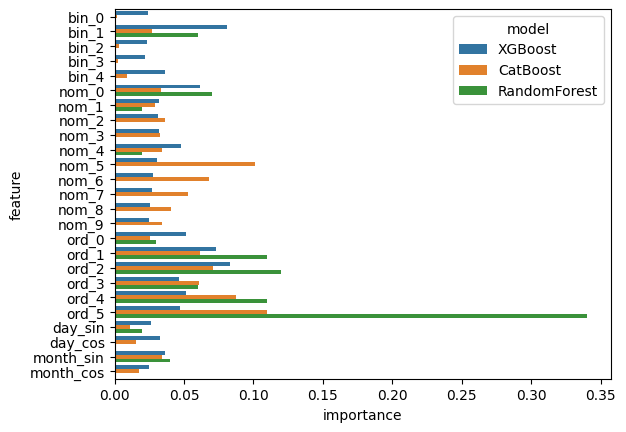

In [45]:
models = [("XGBoost", XGBClassifier(max_depth=7, n_estimators=1000, device="cpu", n_jobs=-1, 
                    gamma=1, subsample=0.9, colsample_bytree=0.5)),
          ("CatBoost", CatBoostClassifier(verbose=0)),
          ("RandomForest", RandomForestClassifier(max_depth=1, n_estimators=100, n_jobs=-1))]

rez = {}

all_importances = []

for name, model in models:

    model.fit(X_train, Y_train)
    rez[name] = {'train ROC AUC': roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]),
                'test ROC AUC': roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]),
                'test Accuracy': accuracy_score(Y_test, model.predict(X_test))}

    importances = model.feature_importances_
    importances = importances / importances.sum()
    
    df_imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importances,
        "model": name
    })

    all_importances.append(df_imp)

imp_df = pd.concat(all_importances, ignore_index=True)

sns.barplot(
    data=imp_df,
    x="importance",
    y="feature",
    hue="model"
)
    
rez_df = pd.DataFrame(rez)
rez_df

По этому графику видно, что Случайный лес проигнорировал категориальные столбцы. Вероятно, что именно с этим и связано его худшее качество по сравнению с другими моделями.

### SHAP 

SHAP расшифровывается как SHapley Additive exPlanations. Этот метод на данный момент является золотым стандартом при объяснении моделей бустинга и случайного леса.

Для оценки важности тут используется идея из **Теории Игр**. Легко провести аналогию между признаками в модели и коалиционными играми. Самым простым примером коалиционной игры является голосование.

Важность признака оценивается на основании того, как изменяются предсказания, при добавлении его во всевозможные подмножества других признаков.

**SHAP** позволяет оценивать важность признака и его вклад по конкретным точкам этой выборки, а не по всей выборке, как это делает *feature_importance* на основании *Gain*.

Предсказание модели буквально раскладывается на сумму вкладов каждого из признаков:

$$f(x) = \phi_0 + \sum_{i=1}^{M}\phi_i,$$
 
где $\phi_0 = \mathbb{E}[f(X)]$ $-$ базовое значение (ожидаемое предсказание модели на всей выборке).

А важность каждого признака оценивается как средневзвешенное приращение предсказания, которое этот признак приносит при добавлении во всевозможные подмножества других признаков:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (M - |S| - 1)!}{M!} [f_x(S \cup \{i\}) - f_x(S)],$$
где 
- $N$ $-$ множество всех признаков, $M$ $-$ их общее количество. 

- $S$ $-$ подмножество признаков, не включающее $i$.

- $f_x(S)$ $-$ предсказание модели, когда нам известны только признаки из набора $S$. 

- $[f_x(S \cup \{i\}) - f_x(S)]$ — вклад признака $i$. Мы смотрим, насколько изменился прогноз, когда $i$ добавился к группе $S$.

- $\frac{|S|! (M - |S| - 1)!}{M!}$ — весовой коэффициент (обратное количество перестановок). Он учитывает, что существует множество способов собрать коалицию размера $|S|$.

Для вычисления вклада признаков используется именно такая формула потому что доказано, что только такое распределение вкладов удовлетворяет всем четырём ограничениям:
- Эффективность: Сумма вкладов признаков равна разности между текущим предсказанием и средним предсказанием.
- Аксиома болвана: Если признак не меняет предсказание ни в одной коалиции, его $\phi_i = 0$. То есть бесполезный признак будет иметь вклад 0.
- Симметричность: Если два признака вносят одинаковый вклад во все коалиции, их вклады равны.
- Линейность: Если модель — это сумма двух подмоделей, то SHAP-значение для общей модели равно сумме SHAP-значений этих подмоделей.

Про вычисление SHAP нужно заметить следующее: вычисление $[f_x(S \cup \{i\}) - f_x(S)]$ $-$ это сложно. Для вычисления "по-честному" потребуется обучить модель на каждом подмножестве признаков, что не представляется возможном в связи с комбинаторным взрывом $-$ всего $2^M$ комбинаций. Да и задача стоит немного по-другому $-$ оценить важность признаков не вообще, а для конкретной обученной модели.

К вычисления $f_x(S)$ можно подойти через условное распределение: $f_x(S) = E[f(X) \mid X_S = x_S]$. То есть для точки данных $x$ мы фиксируем признаки из множества $S$, а по остальным берём ожидание. Но это тоже не лучший подход $-$ необходимо знать совместное распределение $P(X)$ всех признаков. Далее можно подходить с разными идеями аппроксимации распределения $P(x)$, к примеру, можно предположить, что признаки независимы, хотя это точно не так.

Но для деревьев принятия решений есть свой трюк, называемый **TreeSHAP**. При нахождении в узле, где разбиение идёт по признаку, которого нет в подмножестве $S$, можно проигнорировать это разбиение и пойти в обе ветки сразу. Результаты разных веток потом необходимо агрегировать.

Вычисление SHAP можно провести с помощью специальной библиотеки.

In [46]:
import shap

model = XGBClassifier().fit(X_train, Y_train)

# TreeExplainer автоматически подстраивается под структуру популярных библиотек
explainer = shap.TreeExplainer(model)

# Расчет SHAP значений для тестовой выборки
shap_values = explainer.shap_values(X_test)

/home/ivanbalashov/LearningMachine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Часто SHAP изображают на следующих графиках. Для понимания графика важно помнить, что SHAP считается для каждой точки поданной на вход выборки.
- Для каждого признака рисуется распределение вкладов $\phi_i$.
- Цветом обозначается значение признака. Синие значения $-$ значение признака меньше, красные значения $-$ значение признака больше. 

Там, где распределение более разбросано в стороны $-$ признаки более важные. На графике признаки как раз распределены сверху вниз от более важных к менее важным.

Плавный переход от синего к красному может показывать общее влияние признака на результат $-$ увеличивает вероятность принадлежности классу или уменьшает. 

Явно видно, что ординальные признаки имеют простую зависимость: значение больше $-$ вероятность принадлежности классу 1 больше. 

С номинальными признаками nom_0-nom_4 тоже видно, что модель смогла их корректно обработать $-$ на графике выделились явные пятна одного цвета. Заметьте что нет зависимости как в ординальных признаках, что логично, так как разные категории между собой никак не упорядочены.

А вот о номинальных признаках nom_5-nom_7 можно заметить следующее: модель их обработала очень плохо. Всё распределение сосредоточилось вокруг нуля. Это явно говорит о том, что признак плохо обработан.

Признаки nom_8 и nom_9 тут и вовсе не отображены, так как совсем неинформативны.

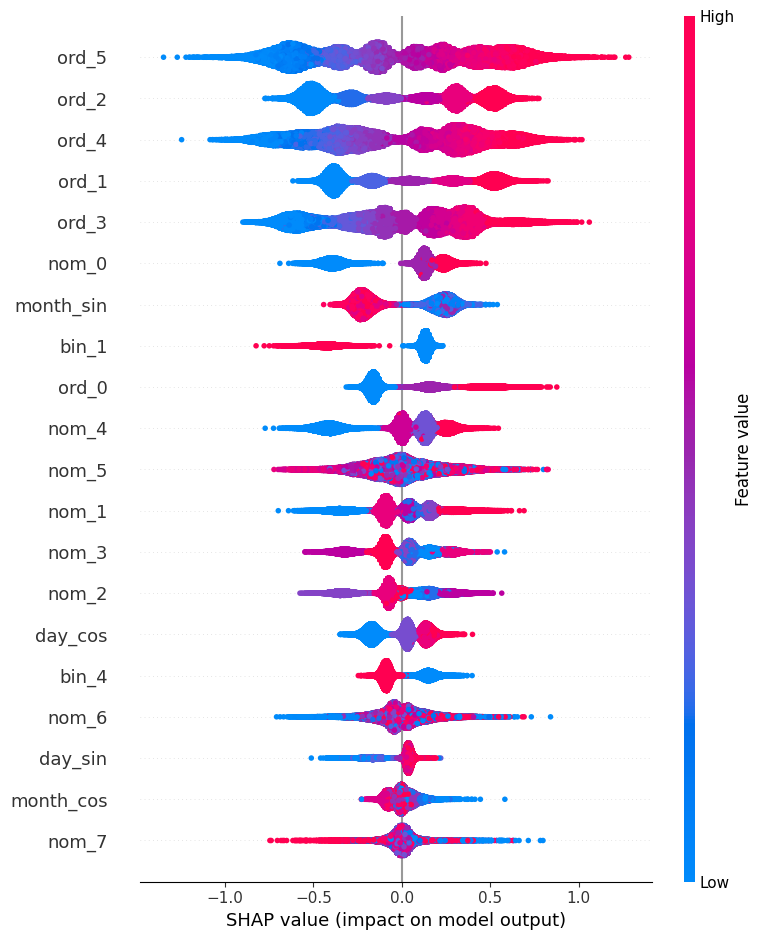

In [47]:
shap.summary_plot(shap_values, X_test, feature_names=X_train.columns)

На следующем графике можно отобразить вклад каждого признака в предсказание для конкретной точки данных. Одни признаки вероятность принадлежности первому классу увеличивают, другие уменьшают, причём мы видим конкретную величину изменения. Это позволяет дать простое пояснение при объяснении модели: "Признак X имеет значение Y, поэтому ответ на Z больше".

In [48]:
shap.initjs() # Нужно для отображения в Jupyter
shap.force_plot(explainer.expected_value, shap_values[1,:], X_test.iloc[1,:])

Для вычисления SHAP для в CatBoost есть специальный метод, который работает лучше чем "универсальный" метод из библиотеки `shap`. Связано это непосредственно с структурой получаемых в CatBoost деревьев.

In [50]:
params = {'loss_function': 'CrossEntropy', 
              'eval_metric': "AUC",
              'learning_rate': 0.01,
              'iterations': 1000,
              'random_seed': 42,
              'od_type': "Iter",
              'early_stopping_rounds': 500,
             }

X_train1, X_val1, Y_train1, Y_val1 = train_test_split(X_train, Y_train, test_size=0.3)

_train = Pool(X_train1, label=Y_train1, cat_features=categorical_features_indices)
_val = Pool(X_val1, label=Y_val1, cat_features=categorical_features_indices)
_test = Pool(X_test, label=Y_test, cat_features=categorical_features_indices)

model = CatBoostClassifier(**params)

fit_model = model.fit(_train,
                    eval_set=_val,
                    use_best_model=True,
                    verbose=0,
                    plot=False)

# 
shap_values = model.get_feature_importance(_test, type='ShapValues')

Тут мы можем увидеть, что модель намного лучше задействовала категориальные признаки в предсказаниях.

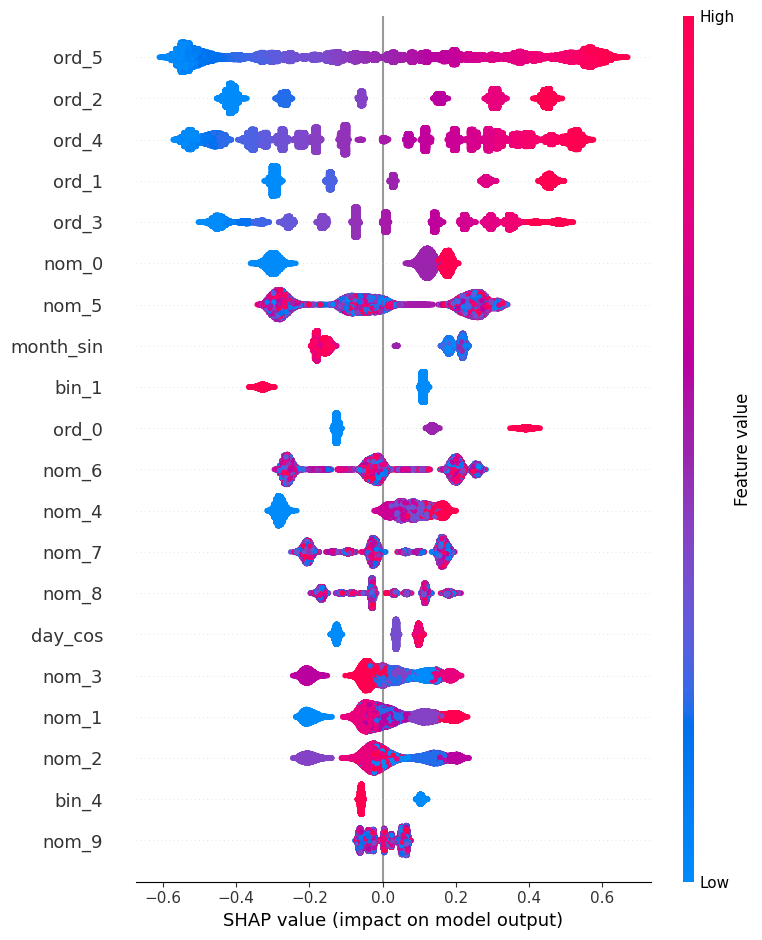

In [51]:
shap.summary_plot(shap_values[:,:-1], X_test, feature_names=X_train.columns)

# Домашнее задание

- На рассмотренном наборе данных используйте изученные модели градиентного бустинга: XGBoost, catBoost и LightGBM. Обучите эти модели, попробуйте обучить гиперпараметры.
- Попробуйте использовать *Гистограммный метод* в XGBoost и CatBoost, обратите внимание на изменение времени обучения.
- Обучите гиперпараметры для XGBoost и LightGBM с обработкой категориальных признаков.
    
**Совет:** Не указывайте слишком большие значения параметров. Для кросс-валидации используйте *ReandomSearchCV*. Для обучения XGBoost или catBoost при возможности задействуйте GPU. Если обучение затягивается больше чем на 15-20 минут $-$ его точно стоит остановить.

- Вычислите для случайного леса и для LightGBM значения SHAP. Отобразите и проанализируйте важность признаков по SHAP.



In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.8, stratify=Y, random_state=43)

n_iter = 30
cv = 3

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

param_dist_xgb= {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(1, 6),
    "learning_rate": loguniform(1e-3, 0.5),
    "gamma": loguniform(1e-3, 5),
    "reg_lambda": loguniform(1e-3, 10),
}

estimator = XGBClassifier()

total_fits = n_iter * cv

rnd_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist_xgb,
    n_iter=n_iter,
    scoring="roc_auc",
    cv=cv,
    verbose=0,
    n_jobs=-1,
    return_train_score=False
)

rnd_search.fit(X_train, Y_train)
best_params_xgb = rnd_search.best_params_

model = rnd_search.best_estimator_
print("XGBClassifier")
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")
print("Полученные параметры:")
print(rnd_search.best_params_)


param_dist_cbs = {
    "iterations": randint(100, 1000),
    "depth": randint(1, 6),
    "learning_rate": loguniform(1e-3, 0.5),
    "l2_leaf_reg": loguniform(1e-3, 10),
    "random_strength": loguniform(1e-3, 10),
    "border_count": randint(32, 255),
}

print("CatBoostClassifier")

estimator = CatBoostClassifier(
    verbose=0,
    task_type="CPU",
    random_seed=42,
)


rnd_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist_cbs,
    n_iter=n_iter,
    scoring="roc_auc",
    cv=cv,
    verbose=0,
    n_jobs=-1,
    return_train_score=False,
    random_state=42
)

rnd_search.fit(X_train, Y_train)
best_params_ctb = rnd_search.best_params_
model = rnd_search.best_estimator_

print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

print("\nЛучшие параметры:")
print(rnd_search.best_params_)


best_params = {
    'colsample_bytree': 0.6702599620885155,
    'learning_rate': 0.05579886345232659,
    'max_depth': 5,
    'n_estimators': 411,
    'num_leaves': 26,
    'reg_lambda': 1.0556531225832042,
    'subsample': 0.6785358610717214,
}

estimator = LGBMClassifier(
    random_state=42,
    verbose=0,
    n_jobs=-1,
    **best_params
)

print("LightGBM")
estimator.fit(X_train, Y_train)

print(f"train ROC AUC: {roc_auc_score(Y_train, estimator.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, estimator.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, estimator.predict(X_test)):.4f}")



XGBClassifier
train ROC AUC: 0.7983
test ROC AUC: 0.7730
test Accuracy: 0.7465
Полученные параметры:
{'gamma': np.float64(0.016117354772770133), 'learning_rate': np.float64(0.2368763752143678), 'max_depth': 2, 'n_estimators': 710, 'reg_lambda': np.float64(0.21052977185444427)}
CatBoostClassifier
train ROC AUC: 0.7723
test ROC AUC: 0.7693
test Accuracy: 0.7449

Лучшие параметры:
{'border_count': 149, 'depth': 1, 'iterations': 791, 'l2_leaf_reg': np.float64(0.02847858516856297), 'learning_rate': np.float64(0.4195760518695597), 'random_strength': np.float64(7.076022085822011)}
LightGBM
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [70]:
import time

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=43)

print("\nXGBoost-hist")
t0 = time.time()
xgb_hist = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                          tree_method='hist', gamma=0.1, reg_lambda=1)
xgb_hist.fit(X_train, Y_train)
t1 = time.time()


print(f"time: {t1-t0:.2f}s")
print(f"test ROC AUC: {roc_auc_score(Y_test, xgb_hist.predict_proba(X_test)[:,1]):.4f}")

print("\nXGBoost")
t0 = time.time()
xgb_hist = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, gamma=0.1, reg_lambda=1)
xgb_hist.fit(X_train, Y_train)
t1 = time.time()


print(f"time: {t1-t0:.2f}s")
print(f"test ROC AUC: {roc_auc_score(Y_test, xgb_hist.predict_proba(X_test)[:,1]):.4f}")

print("\nCatBoost-hist")

t0 = time.time()
cb_hist = CatBoostClassifier(iterations=300, max_depth=6, learning_rate=0.1,
                              feature_border_type='GreedyLogSum', verbose=0)
cb_hist.fit(X_train, Y_train)
t1 = time.time()


print(f"time: {t1-t0:.2f}s")
print(f"test ROC AUC: {roc_auc_score(Y_test, cb_hist.predict_proba(X_test)[:,1]):.4f}")



XGBoost-hist
time: 2.63s
test ROC AUC: 0.7719

XGBoost
time: 2.63s
test ROC AUC: 0.7719

CatBoost-hist
time: 4.07s
test ROC AUC: 0.7733


In [81]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.7, stratify=Y, random_state=43)
print("XGBoost-category")
X_train_c = X_train.copy()
X_test_c = X_test.copy()
cat_cols = [col for col in X_train_c.columns if "nom" in col or "bin" in col]
for col in cat_cols:
    X_train_c[col] = X_train_c[col].astype("category")
    X_test_c[col] = X_test_c[col].astype("category")

rnd_xgb_cat = XGBClassifier(random_state=42,verbode=0,n_jobs=-1,**best_params_xgb, enable_categorical=True, max_cat_to_onehot=6)
rnd_xgb_cat.fit(X_train_c, Y_train)
print(f"test ROC AUC: {roc_auc_score(Y_test, rnd_xgb_cat.predict_proba(X_test_c)[:,1]):.4f}")

print("LightGBM")
estimator = LGBMClassifier(
    random_state=42,
    verbose=0,
    n_jobs=-1,
    **best_params
)
estimator.fit(X_train_c, Y_train)
print(f"test ROC AUC: {roc_auc_score(Y_test, estimator.predict_proba(X_test_c)[:,1]):.4f}")

XGBoost-category
test ROC AUC: 0.7508
LightGBM
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

RandomForest


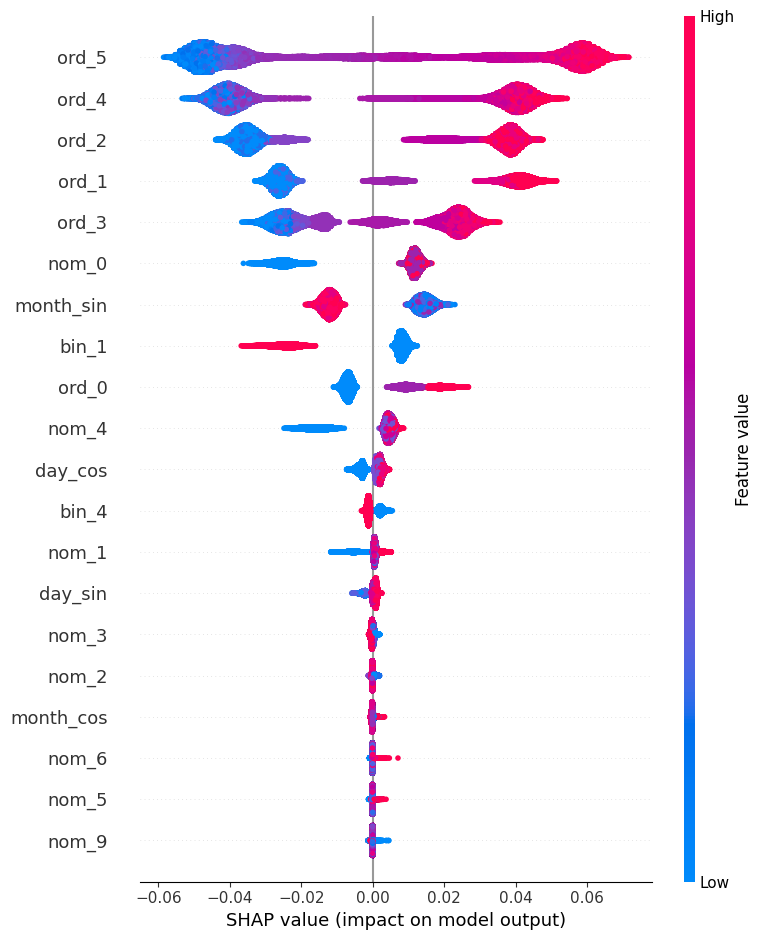

LightGB


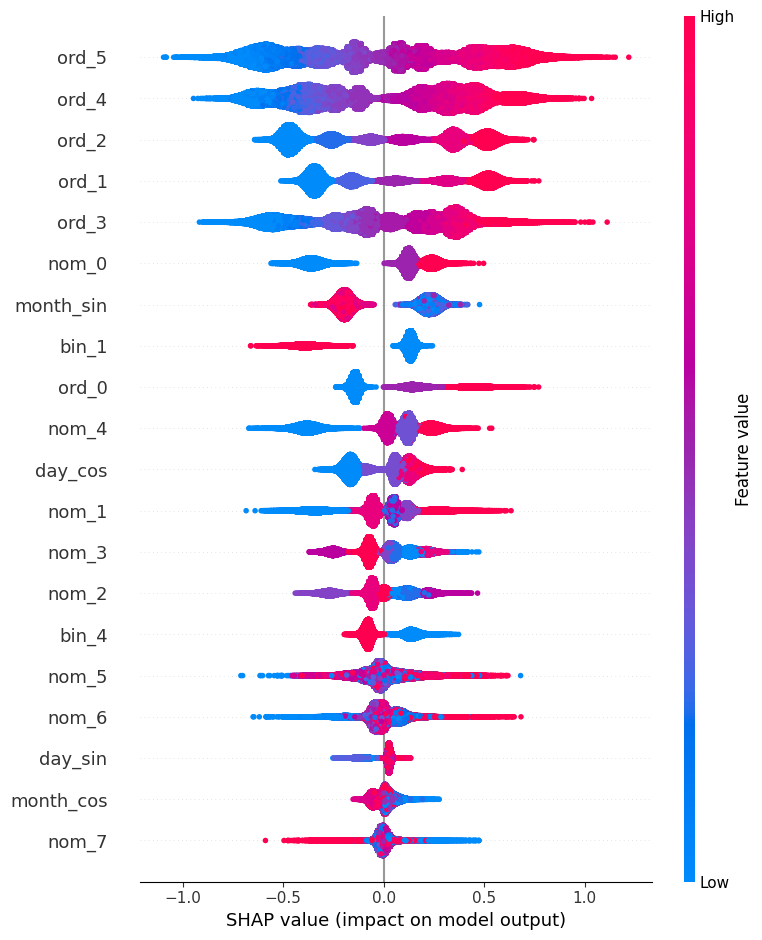

In [82]:
print("RandomForest")


rf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1)
rf.fit(X_train, Y_train)

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf[:, :, 1], X_test, feature_names=X_train.columns)



print("LightGB")

lgb_shap = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, verbose=-1)
lgb_shap.fit(X_train, Y_train)
explainer_lgb = shap.TreeExplainer(lgb_shap)
shap_values_lgb = explainer_lgb.shap_values(X_test)

shap.summary_plot(shap_values_lgb, X_test, feature_names=X_train.columns)